## *Import Libraries*

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path

## *Load Dataset and Inspect Structure*

In [2]:
train_df = pd.read_csv("/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/train.csv")
sample_df = pd.read_csv("/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/sample_submission.csv")

print("Train shape:", train_df.shape)
print("Sample submission shape:", sample_df.shape)
print()
print("Train columns:")
print(train_df.columns.tolist())
print()
train_df.head()

Train shape: (51043, 21)
Sample submission shape: (10, 21)

Train columns:
['id', 'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax', 'Pneumoperitoneum', 'Pneumomediastinum', 'Subcutaneous Emphysema', 'Tortuous Aorta', 'Calcification of the Aorta', 'No Finding']



,id,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,...,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax,Pneumoperitoneum,Pneumomediastinum,Subcutaneous Emphysema,Tortuous Aorta,Calcification of the Aorta,No Finding
0,977df638b5294072ac81c369e2d9ecd0.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,4f6dd5e39cd548df904b7319b13a40c5.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,8772d25762484c2aa3f3e124d2ebcb30.png,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,31caeb0fa0814858bf4591bc1c8d63ac.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,9cd3df7acfbf4bb8a00466801469b08b.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


## *Target Classes* 

In [3]:
# First column is image id, remaining 20 are class labels
image_id_col = train_df.columns[0]
class_columns = train_df.columns[1:].tolist()

print("Image ID column:", image_id_col)
print()
print("Total number of classes:", len(class_columns))
print()
print("Class names:")
for i, cls in enumerate(class_columns):
    print(f"  {i+1:2d}. {cls}")

Image ID column: id

Total number of classes: 20

Class names:
   1. Atelectasis
   2. Cardiomegaly
   3. Consolidation
   4. Edema
   5. Effusion
   6. Emphysema
   7. Fibrosis
   8. Hernia
   9. Infiltration
  10. Mass
  11. Nodule
  12. Pleural_Thickening
  13. Pneumonia
  14. Pneumothorax
  15. Pneumoperitoneum
  16. Pneumomediastinum
  17. Subcutaneous Emphysema
  18. Tortuous Aorta
  19. Calcification of the Aorta
  20. No Finding


## *Validating One-Hot Encoding* 

In [4]:
# Each row should have exactly one 1
row_sums = train_df[class_columns].sum(axis=1)

print("Row sum statistics :")
print(row_sums.value_counts())
print()

# Check for any corrupted rows
invalid_rows = train_df[row_sums != 1]
print("Rows with invalid one-hot encoding:", len(invalid_rows))

Row sum statistics :
1    51043
Name: count, dtype: int64

Rows with invalid one-hot encoding: 0


## *Class Distribution Analysis*

In [5]:
class_counts = train_df[class_columns].sum().sort_values(ascending=False)

print("Class distribution (sample count per class):")
print(class_counts.to_string())
print()
print("Most common class:", class_counts.idxmax(), "with", class_counts.max(), "samples")
print("Least common class:", class_counts.idxmin(), "with", class_counts.min(), "samples")
print("Imbalance ratio (max/min):", round(class_counts.max() / class_counts.min(), 2))

Class distribution (sample count per class):
No Finding                    34079
Infiltration                   5206
Atelectasis                    2351
Effusion                       2156
Nodule                         1527
Mass                           1249
Pneumothorax                   1114
Consolidation                   651
Pleural_Thickening              608
Cardiomegaly                    600
Fibrosis                        389
Edema                           326
Tortuous Aorta                  254
Emphysema                       172
Pneumonia                       160
Calcification of the Aorta       91
Pneumoperitoneum                 44
Hernia                           37
Subcutaneous Emphysema           24
Pneumomediastinum                 5

Most common class: No Finding with 34079 samples
Least common class: Pneumomediastinum with 5 samples
Imbalance ratio (max/min): 6815.8


## *Visualize Class Distribution*

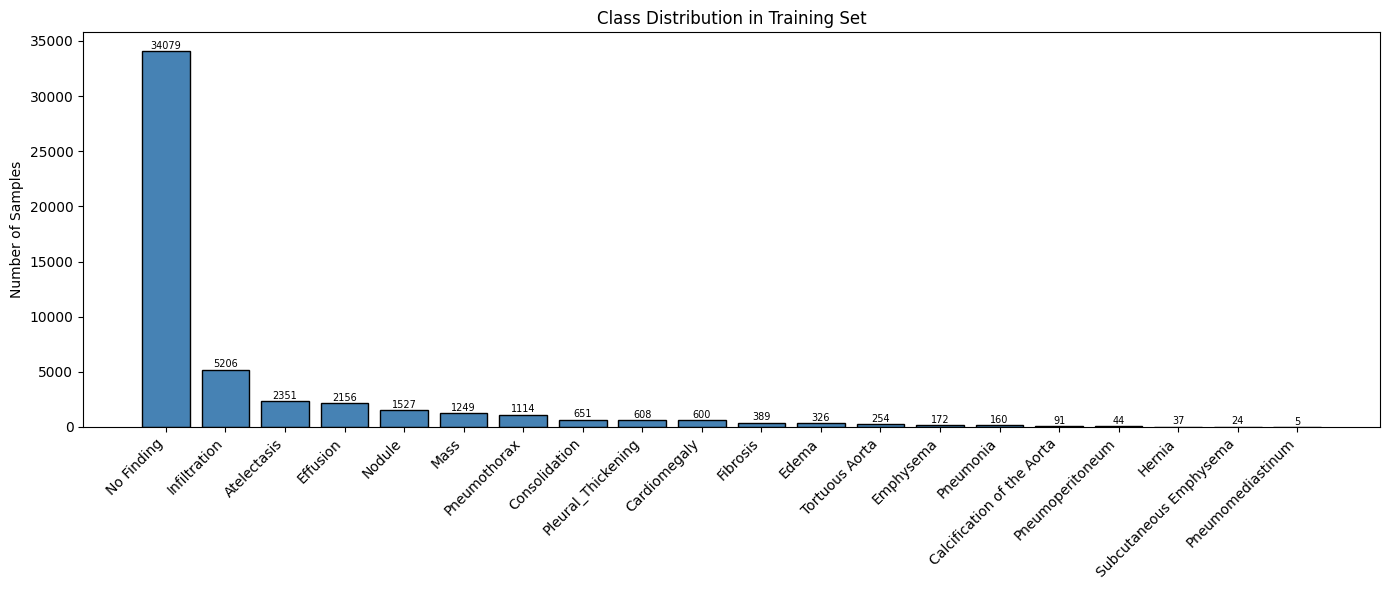

In [6]:
plt.figure(figsize=(14, 6))
bars = plt.bar(class_counts.index, class_counts.values, color="steelblue", edgecolor="black")
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.ylabel("Number of Samples")
plt.title("Class Distribution in Training Set")
plt.tight_layout()

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 30, str(int(height)),
             ha="center", va="bottom", fontsize=7)

plt.savefig("class_distribution.png", dpi=150)
plt.show()

## *Sample Images Per Class*

Total images in directory: 88337

Sample image filenames:
  32258b566bba41018fbfbc8cce95d6dc.png
  c653d938386447e58ab9a53f7100fa46.png
  1760d71394de469aa5fb39efbeee905b.png
  eca6f027f8df442b9d7ff417f9f44f9d.png
  eb307364f199495a90644e1834572135.png


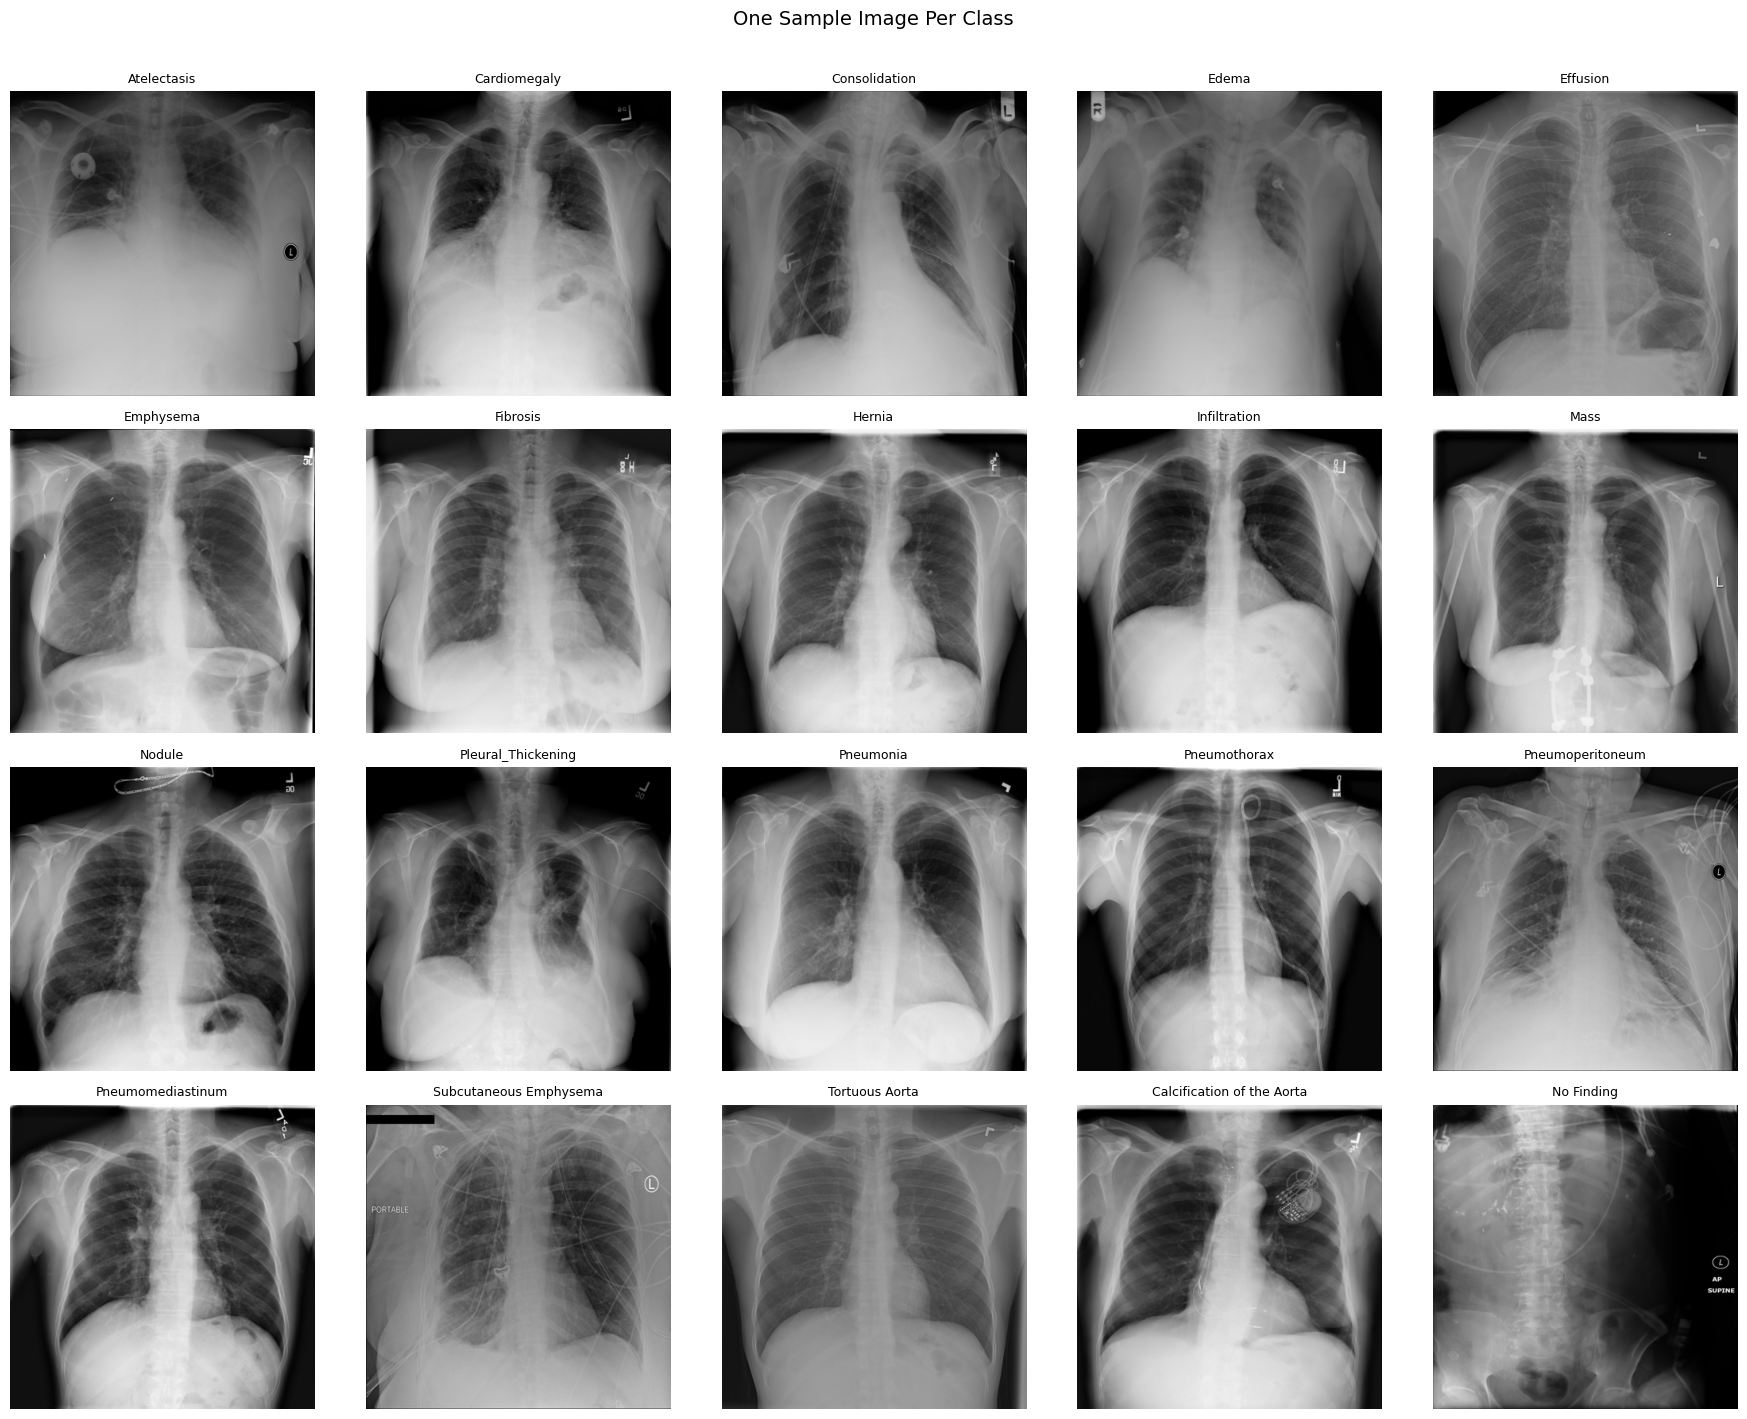

In [7]:
image_dir = Path("/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/images")

all_images = list(image_dir.glob("*.png"))
print("Total images in directory:", len(all_images))
print()
print("Sample image filenames:")
for img in all_images[:5]:
    print(" ", img.name)


fig, axes = plt.subplots(4, 5, figsize=(18, 14))
axes = axes.flatten()

for i, cls in enumerate(class_columns):
    sample_row = train_df[train_df[cls] == 1].iloc[0]
    img_path = image_dir / sample_row[image_id_col]
    img = mpimg.imread(str(img_path))
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(cls, fontsize=9)
    axes[i].axis("off")

plt.suptitle("One Sample Image Per Class", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("sample_images_per_class.png", dpi=150)
plt.show()

## *Verify Image-Label Alignment*

In [8]:
image_filenames = set([img.name for img in all_images])
label_filenames = set(train_df[image_id_col].values)

matched = image_filenames & label_filenames
unmatched_labels = label_filenames - image_filenames
unmatched_images = image_filenames - label_filenames

print("Images with matching labels:", len(matched))
print("Labels without images:", len(unmatched_labels))
print("Images without labels:", len(unmatched_images))


Images with matching labels: 51043
Labels without images: 0
Images without labels: 37294


## *Summary Statistics*

In [9]:
print("Dataset Summary")
print()
print("Total training samples   :", len(train_df))
print("Total test samples       : 17015")
print("Total classes            :", len(class_columns))
print("Image ID column          :", image_id_col)
print()
print("Top 3 most frequent classes:")
print(class_counts.head(3).to_string())
print()
print("Top 3 rarest classes:")
print(class_counts.tail(3).to_string())
print()
print("Class percentage distribution:")
class_pct = (class_counts / len(train_df) * 100).round(2)
print(class_pct.to_string())


Dataset Summary

Total training samples   : 51043
Total test samples       : 17015
Total classes            : 20
Image ID column          : id

Top 3 most frequent classes:
No Finding      34079
Infiltration     5206
Atelectasis      2351

Top 3 rarest classes:
Hernia                    37
Subcutaneous Emphysema    24
Pneumomediastinum          5

Class percentage distribution:
No Finding                    66.77
Infiltration                  10.20
Atelectasis                    4.61
Effusion                       4.22
Nodule                         2.99
Mass                           2.45
Pneumothorax                   2.18
Consolidation                  1.28
Pleural_Thickening             1.19
Cardiomegaly                   1.18
Fibrosis                       0.76
Edema                          0.64
Tortuous Aorta                 0.50
Emphysema                      0.34
Pneumonia                      0.31
Calcification of the Aorta     0.18
Pneumoperitoneum               0.09
Hernia 

## *Analyze Image Resolution and Format*

In [10]:
import cv2
from collections import Counter

# Sample 500 images to analyze resolution and format
sample_images = all_images[:500]

heights = []
widths = []
channels_list = []

for img_path in sample_images:
    img = cv2.imread(str(img_path))
    if img is not None:
        h, w = img.shape[:2]
        c = 1 if len(img.shape) == 2 else img.shape[2]
        heights.append(h)
        widths.append(w)
        channels_list.append(c)

print("Image Resolution Analysis (based on 500 samples)")
print()
print("Height   | Min:", min(heights), " Max:", max(heights), " Mean:", round(np.mean(heights), 1))
print("Width    | Min:", min(widths), " Max:", max(widths), " Mean:", round(np.mean(widths), 1))
print()
print("Unique resolutions found:", len(set(zip(heights, widths))))
print()
print("Channel distribution:")
channel_counts = Counter(channels_list)
for k, v in channel_counts.items():
    print(f"  {k} channel(s): {v} images")

Image Resolution Analysis (based on 500 samples)

Height   | Min: 384  Max: 384  Mean: 384.0
Width    | Min: 384  Max: 384  Mean: 384.0

Unique resolutions found: 1

Channel distribution:
  3 channel(s): 500 images


## *Install and Import Preprocessing Libraries*

In [11]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

2026-03-22 02:51:30.875090: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774147891.092176      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774147891.160866      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774147891.687976      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774147891.688019      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774147891.688022      55 computation_placer.cc:177] computation placer alr

## *Convert One-Hot Labels to Single Integer Label*
*CSV has 20 columns of 0s and 1s. Keras does not want 20 columns as the label. It wants a single number like  0 ,  3 , or  14  representing which class it is*

In [12]:
# Model needs a single class index per image, not one-hot
train_df["label"] = train_df[class_columns].values.argmax(axis=1)

print("Label column added successfully")
print()
print("Label distribution (integer class index):")
print(train_df["label"].value_counts().sort_index())

Label column added successfully

Label distribution (integer class index):
label
0      2351
1       600
2       651
3       326
4      2156
5       172
6       389
7        37
8      5206
9      1249
10     1527
11      608
12      160
13     1114
14       44
15        5
16       24
17      254
18       91
19    34079
Name: count, dtype: int64


## *Map Class Index to Class Name*

In [13]:
label_to_class = {i: cls for i, cls in enumerate(class_columns)}
class_to_label = {cls: i for i, cls in enumerate(class_columns)}

print("Class index mapping:")
for idx, cls in label_to_class.items():
    print(f"  {idx:2d} : {cls}")

Class index mapping:
   0 : Atelectasis
   1 : Cardiomegaly
   2 : Consolidation
   3 : Edema
   4 : Effusion
   5 : Emphysema
   6 : Fibrosis
   7 : Hernia
   8 : Infiltration
   9 : Mass
  10 : Nodule
  11 : Pleural_Thickening
  12 : Pneumonia
  13 : Pneumothorax
  14 : Pneumoperitoneum
  15 : Pneumomediastinum
  16 : Subcutaneous Emphysema
  17 : Tortuous Aorta
  18 : Calcification of the Aorta
  19 : No Finding


## *Train Validation Split*

In [14]:
# Stratified split to preserve class distribution in both sets
train_split, val_split = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df["label"]
)

train_split = train_split.reset_index(drop=True)
val_split = val_split.reset_index(drop=True)

print("Training samples  :", len(train_split))
print("Validation samples:", len(val_split))

Training samples  : 40834
Validation samples: 10209


## *Compute Class Weights*

In [15]:
class_labels = train_split["label"].values

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(class_labels),
    y=class_labels
)

class_weight_dict = {i: min(w, 20.0) for i, w in enumerate(class_weights_array)}

print("Capped class weights:")
for idx, weight in class_weight_dict.items():
    print(f"  {label_to_class[idx]:<35}: {round(weight, 4)}")

Capped class weights:
  Atelectasis                        : 1.0854
  Cardiomegaly                       : 4.2535
  Consolidation                      : 3.9188
  Edema                              : 7.8226
  Effusion                           : 1.1836
  Emphysema                          : 14.7949
  Fibrosis                           : 6.565
  Hernia                             : 20.0
  Infiltration                       : 0.4902
  Mass                               : 2.0437
  Nodule                             : 1.6722
  Pleural_Thickening                 : 4.201
  Pneumonia                          : 15.9508
  Pneumothorax                       : 2.2915
  Pneumoperitoneum                   : 20.0
  Pneumomediastinum                  : 20.0
  Subcutaneous Emphysema             : 20.0
  Tortuous Aorta                     : 10.0576
  Calcification of the Aorta         : 20.0
  No Finding                         : 0.0749


## *Image Size and Paths*
*EfficientNetB0 was trained on ImageNet using 224x224 images. If you feed it a different size, the pretrained knowledge does not map correctly*

In [16]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
IMAGE_DIR = str(image_dir)

# Zero pad labels so they sort correctly as strings
# '0' becomes '00', '1' becomes '01', ..., '19' stays '19'
# This ensures alphabetical sort matches numerical sort
train_split["label_str"] = train_split["label"].apply(lambda x: f"{x:02d}")
val_split["label_str"] = val_split["label"].apply(lambda x: f"{x:02d}")

print("Sample label_str values:", train_split["label_str"].unique()[:5])

Sample label_str values: ['19' '00' '10' '08' '09']


## *Data Augmentation for Training Set*

In [17]:
# Light augmentation suitable for medical X-ray images
# Avoid aggressive augmentation like heavy color shifts
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05
)

# Validation only rescaled, no augmentation
val_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

## *Data Generators*

In [18]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_split,
    directory=IMAGE_DIR,
    x_col=image_id_col,
    y_col="label_str",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_split,
    directory=IMAGE_DIR,
    x_col=image_id_col,
    y_col="label_str",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("Class indices:")
print(train_generator.class_indices)

Found 40834 validated image filenames belonging to 20 classes.
Found 10209 validated image filenames belonging to 20 classes.
Class indices:
{'00': 0, '01': 1, '02': 2, '03': 3, '04': 4, '05': 5, '06': 6, '07': 7, '08': 8, '09': 9, '10': 10, '11': 11, '12': 12, '13': 13, '14': 14, '15': 15, '16': 16, '17': 17, '18': 18, '19': 19}


## *Verifying with a Single Batch*

In [19]:
images, labels = next(train_generator)

print("Batch shape     :", images.shape)
print("Label shape     :", labels.shape)
print("Pixel min/max   :", round(images.min(), 3), "/", round(images.max(), 3))
print("Sample labels   :", labels[:5])
print("Sample classes  :", [label_to_class[int(l.argmax())] for l in labels[:5]])

Batch shape     : (32, 224, 224, 3)
Label shape     : (32, 20)
Pixel min/max   : 0.0 / 1.0
Sample labels   : [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]
Sample classes  : ['No Finding', 'Atelectasis', 'No Finding', 'No Finding', 'No Finding']


## *Model Building* 

In [20]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

# Load EfficientNetB0 pretrained on ImageNet, exclude its top classification layer
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze all pretrained layers so they do not get updated during training
base_model.trainable = False

# Add our own classification head on top
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(20, activation="softmax")
])

model.summary()

I0000 00:00:1774147977.351551      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774147977.357531      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,216,119 (16.08 MB)

 Trainable params: 166,548 (650.58 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [21]:
# Using categorical_crossentropy because generator now outputs one-hot vectors
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully")

Model compiled successfully


## *Model Training*

In [22]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Stop training if validation loss does not improve for 3 epochs
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Save the best model automatically
checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

*If your validation loss stops improving, there is no point continuing training. EarlyStopping watches  val_loss  and if it does not improve for 5 consecutive epochs ( patience=5 ), it stops training automatically. This saves GPU time and prevents overfitting.*

In [23]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print("Training complete")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15


I0000 00:00:1774147991.281386     132 service.cc:152] XLA service 0x79a68c114140 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774147991.281424     132 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774147991.281428     132 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774147993.638998     132 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-22 02:53:20.426307: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-22 02:53:20.570104: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-22 02:53:20.904890: E external/local_xl

1234/1277 ━━━━━━━━━━━━━━━━━━━━ 24s 565ms/step - accuracy: 0.6582 - loss: 1.5802

2026-03-22 03:05:11.129936: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-22 03:05:11.262316: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-22 03:05:11.567851: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-22 03:05:11.707751: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-22 03:05:11.847720: E external/local_xla/xla/stream_

1277/1277 ━━━━━━━━━━━━━━━━━━━━ 0s 574ms/step - accuracy: 0.6585 - loss: 1.5766

2026-03-22 03:07:23.195012: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-22 03:07:23.330501: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-22 03:07:24.030271: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-22 03:07:24.166020: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_loss improved from inf to 1.38739, saving model to best_model.keras
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 868s 658ms/step - accuracy: 0.6585 - loss: 1.5765 - val_accuracy: 0.6676 - val_loss: 1.3874
Epoch 2/15
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.6648 - loss: 1.4305
Epoch 2: val_loss improved from 1.38739 to 1.38095, saving model to best_model.keras
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 627s 491ms/step - accuracy: 0.6648 - loss: 1.4305 - val_accuracy: 0.6676 - val_loss: 1.3809
Epoch 3/15
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.6698 - loss: 1.4034
Epoch 3: val_loss improved from 1.38095 to 1.37965, saving model to best_model.keras
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 621s 486ms/step - accuracy: 0.6698 - loss: 1.4034 - val_accuracy: 0.6676 - val_loss: 1.3797
Epoch 4/15
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.6653 - loss: 1.4139
Epoch 4: val_loss did not improve from 1.37965
1277/1277 ━━━━━━━━━━━━━━━━━━━━ 629s 493ms/step - accuracy: 0.6

## *Training History*

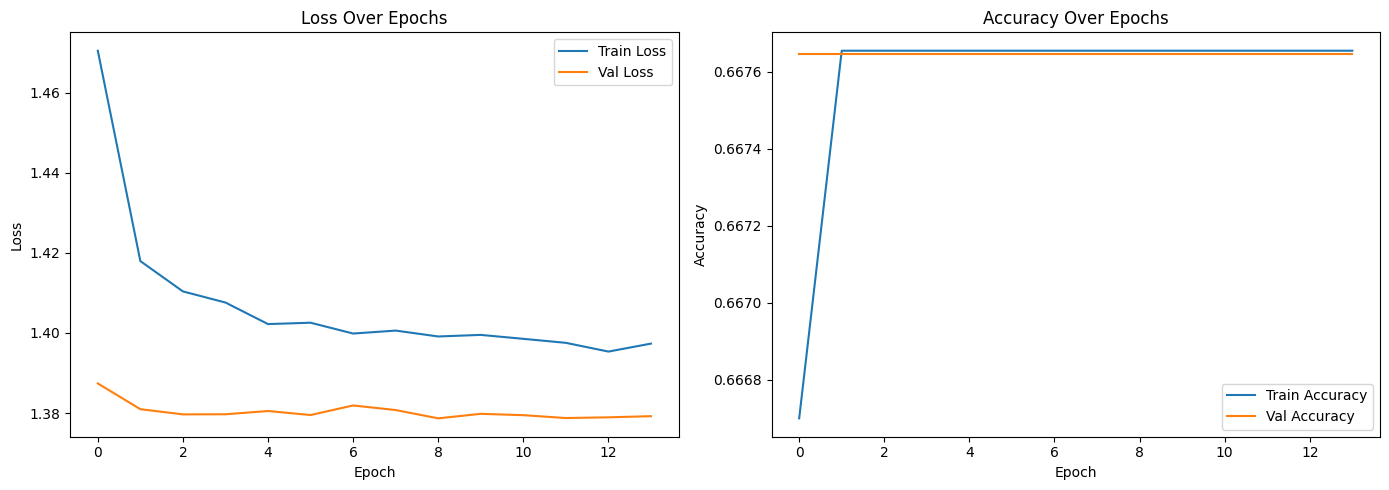

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["loss"], label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Val Loss")676767
axes[0].set_title("Loss Over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="Train Accuracy")
axes[1].plot(history.history["val_accuracy"], label="Val Accuracy")
axes[1].set_title("Accuracy Over Epochs")
axes[1].set_xlabel("Epoch") 
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig("training_history.png", dpi=150)
plt.show()

## *Predictions*

In [25]:
test_df = pd.read_csv("/kaggle/input/competitions/26-t-1-dl-gen-ainppe-1/test.csv")

# Get image id column from sample submission
test_id_col = test_df.columns[0]

print("Test samples:", len(test_df))
print("Test columns:", test_df.columns.tolist())
test_df.head()


Test samples: 17015
Test columns: ['id']


,id
0,7b647fbfcc874a7084a4470fc150e267.png
1,cc804b94d80c4a80a206298c307adfec.png
2,1df09c3becd04de995244caae36ddf57.png
3,044cac47cfdf4c8b90848c9e56c36bfa.png
4,a873523c43664a049c5e8f26add7ecb2.png


In [26]:
test_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=IMAGE_DIR,
    x_col=test_id_col,
    y_col=None,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode=None,
    shuffle=False
)

Found 17015 validated image filenames.


In [27]:
model = tf.keras.models.load_model("best_model.keras")

generator_class_map = {v: label_to_class[int(k)] for k, v in train_generator.class_indices.items()}

predictions = model.predict(test_generator, verbose=1)
predicted_classes = predictions.argmax(axis=1)

print("Predictions shape:", predictions.shape)
print("Sample predicted class names:", [generator_class_map[i] for i in predicted_classes[:5]])

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


531/532 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step

2026-03-22 05:26:45.381540: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-22 05:26:45.524301: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-22 05:26:45.855024: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-22 05:26:45.996806: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-22 05:26:46.716103: E external/local_xla/xla/stream_

532/532 ━━━━━━━━━━━━━━━━━━━━ 176s 319ms/step
Predictions shape: (17015, 20)
Sample predicted class names: ['No Finding', 'No Finding', 'No Finding', 'No Finding', 'No Finding']


In [28]:
# Build submission dataframe with one-hot format
submission_df = pd.DataFrame(columns=[test_id_col] + class_columns)
submission_df[test_id_col] = test_df[test_id_col]

# Fill all class columns with 0
for col in class_columns:
    submission_df[col] = 0

# Set the predicted class column to 1 for each row
for i, class_idx in enumerate(predicted_classes):
    class_name = generator_class_map[class_idx]
    submission_df.at[i, class_name] = 1

# Verify each row sums to exactly 1
assert (submission_df[class_columns].sum(axis=1) == 1).all(), "Some rows do not sum to 1"

submission_df.to_csv("submission.csv", index=False)
print("submission.csv saved successfully")
print("Shape:", submission_df.shape)
submission_df.head()

submission.csv saved successfully
Shape: (17015, 21)


,id,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,...,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax,Pneumoperitoneum,Pneumomediastinum,Subcutaneous Emphysema,Tortuous Aorta,Calcification of the Aorta,No Finding
0,7b647fbfcc874a7084a4470fc150e267.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,cc804b94d80c4a80a206298c307adfec.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,1df09c3becd04de995244caae36ddf57.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,044cac47cfdf4c8b90848c9e56c36bfa.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,a873523c43664a049c5e8f26add7ecb2.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [29]:
# Final check before submitting
check_df = pd.read_csv("submission.csv")

print("Submission Checklist")
print()
print("Total rows              :", len(check_df))
print("Expected rows           : 17015")
print("Total columns           :", len(check_df.columns))
print("Rows summing to 1       :", (check_df[class_columns].sum(axis=1) == 1).sum())
print("Rows with issues        :", (check_df[class_columns].sum(axis=1) != 1).sum())
print()
print("First 3 rows:")
print(check_df.head(3).to_string(index=False))
print()
print("File is ready to upload to Kaggle.")

Submission Checklist

Total rows              : 17015
Expected rows           : 17015
Total columns           : 21
Rows summing to 1       : 17015
Rows with issues        : 0

First 3 rows:
                                  id  Atelectasis  Cardiomegaly  Consolidation  Edema  Effusion  Emphysema  Fibrosis  Hernia  Infiltration  Mass  Nodule  Pleural_Thickening  Pneumonia  Pneumothorax  Pneumoperitoneum  Pneumomediastinum  Subcutaneous Emphysema  Tortuous Aorta  Calcification of the Aorta  No Finding
7b647fbfcc874a7084a4470fc150e267.png            0             0              0      0         0          0         0       0             0     0       0                   0          0             0                 0                  0                       0               0                           0           1
cc804b94d80c4a80a206298c307adfec.png            0             0              0      0         0          0         0       0             0     0       0                   0        